# Importação dos dados



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


## Tratamento dos Dados, com objetivo de otimizar as etapas posteriores que serão:
- Analisar o Faturamento Total de Cada Loja
- Vendas por Categoria
- Média de Avaliação por Loja
- Produtos Mais e Menos Vendidos
- Frete Médio por Loja

In [2]:
pip install seaborn 


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
# Adicionando coluna de identificação da loja (sem alterar a importação original)
loja['loja'] = 'Loja_1'
loja2['loja'] = 'Loja_2'
loja3['loja'] = 'Loja_3'
loja4['loja'] = 'Loja_4'

In [5]:
# Unindo todos os DataFrames em uma única base
df_geral = pd.concat([loja, loja2, loja3, loja4])

In [6]:
# Exibir 5 linhas de cada loja para validar que temos as informações de todas as lojas no Dataframe
amostra_lojas = df_geral.groupby('loja').head(5)
amostra_lojas

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon,loja
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja_1
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,Loja_1
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,Loja_1
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50,Loja_1
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,Loja_1
0,Cadeira de escritório,moveis,378.20,20.421138,04/08/2021,Thiago Silva,MG,1,boleto,1,-18.10,-44.38,Loja_2
1,Pandeiro,instrumentos musicais,102.37,3.035334,26/11/2020,Bianca Santos,RJ,3,cartao_credito,4,-22.25,-42.66,Loja_2
2,Cama king,moveis,591.13,31.759020,22/10/2021,Thiago Silva,SC,5,cartao_credito,10,-27.45,-50.95,Loja_2
3,Cama king,moveis,1208.24,61.919584,04/05/2022,Larissa Alves,RS,5,cartao_credito,10,-30.17,-53.50,Loja_2
4,Cadeira de escritório,moveis,530.41,25.827176,26/02/2022,Lucas Oliveira,SP,4,cartao_credito,3,-22.19,-48.79,Loja_2


# 1. Análise do faturamento


In [7]:
# Valor total por loja
faturamento_por_loja = df_geral.groupby('loja')['Preço'].sum().round(2)

In [8]:
# Calculando o faturamento total das lojas
faturamento_total = faturamento_por_loja.sum()

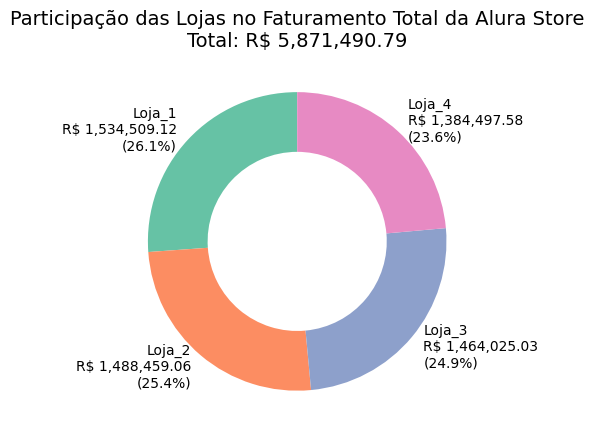

In [9]:
# Valor total geral com nome da loja, valor e percentual

labels = [f'{loja}\nR$ {valor:,.2f}\n({(valor/faturamento_total)*100:.1f}%)' 
          for loja, valor in faturamento_por_loja.items()]

# Gráfico
plt.figure(figsize=(5, 5))
plt.pie(faturamento_por_loja, labels=labels, startangle=90, 
        colors=['#66c2a5','#fc8d62','#8da0cb','#e78ac3'],
        wedgeprops=dict(width=0.4))  # Estilo "donut" elegante

plt.title(f'Participação das Lojas no Faturamento Total da Alura Store\nTotal: R$ {faturamento_total:,.2f}', fontsize=14)
plt.tight_layout()
plt.show()

# 2. Vendas por Categoria


In [10]:
# Contagem de vendas por categoria
vendas_categoria = df_geral['Categoria do Produto'].value_counts().reset_index()
vendas_categoria.columns = ['Categoria do Produto', 'quantidade']


In [11]:
# Cálculo do percentual
vendas_categoria['percentual'] = (vendas_categoria['quantidade'] / vendas_categoria['quantidade'].sum()) * 100

In [12]:
# Cálculo do faturamento total por categoria
faturamento_categoria = df_geral.groupby('Categoria do Produto')['Preço'].sum().reset_index()
faturamento_categoria.columns = ['Categoria do Produto', 'faturamento']

In [13]:
# Juntando tudo
vendas_categoria = vendas_categoria.merge(faturamento_categoria, on='Categoria do Produto')

In [14]:
# Arredondando e reordenando colunas
vendas_categoria['percentual'] = np.ceil(vendas_categoria['percentual'] * 100) / 100
vendas_categoria = vendas_categoria.round({'percentual': 2, 'faturamento': 2})

In [15]:
# Ordenando pelas colunas desejadas
vendas_categoria = vendas_categoria.sort_values(by=['quantidade', 'faturamento', 'percentual'], ascending=False)

In [16]:
# Adicionando linha de total
total_row = pd.DataFrame({
    'Categoria do Produto': ['TOTAL'],
    'quantidade': [vendas_categoria['quantidade'].sum()],
    'faturamento': [vendas_categoria['faturamento'].sum()],
    'percentual': [vendas_categoria['percentual'].sum()]
})

In [17]:
# Concatenando a linha total à tabela
vendas_categoria = pd.concat([vendas_categoria, total_row], ignore_index=True)

print(vendas_categoria.round(1).to_string(index=False))

 Categoria do Produto  quantidade  percentual  faturamento
               moveis        1886        20.0    1010214.0
          eletronicos        1772        18.8    2214099.7
           brinquedos        1290        13.7      98140.9
     eletrodomesticos        1149        12.2    1766337.0
      esporte e lazer        1113        11.8     190635.4
instrumentos musicais         753         8.0     465029.7
               livros         742         7.9      50260.7
utilidades domesticas         730         7.7      76773.4
                TOTAL        9435       100.0    5871490.8


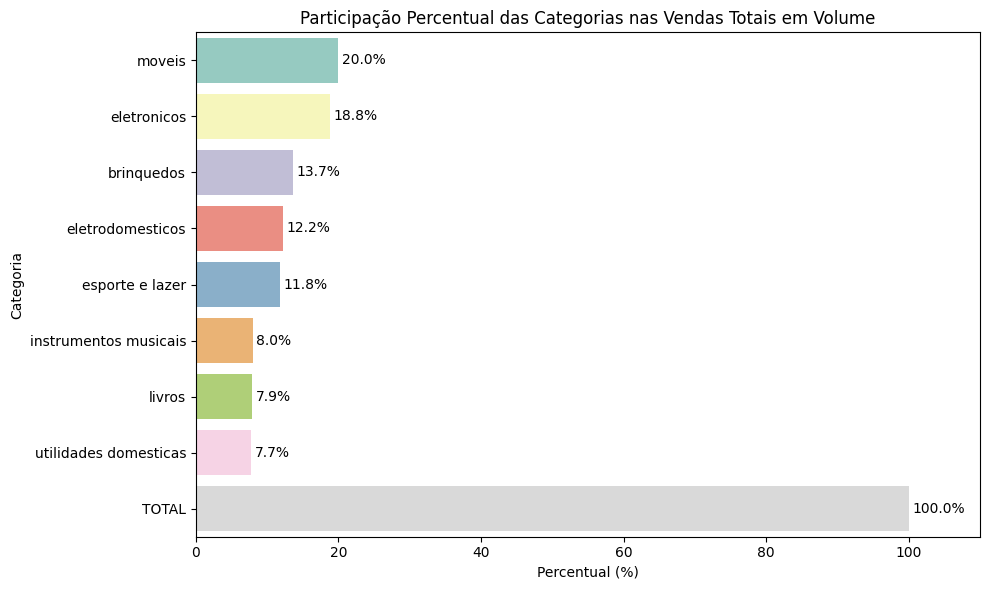

In [47]:
# Supondo que seu DataFrame se chame df_vendas
# E que tenha colunas: ['Produto', 'Categoria do Produto', 'Loja', 'Preço']

# Gráfico de barras com percentual
plt.figure(figsize=(10, 6))
sns.barplot(data=vendas_categoria, x='percentual', y='Categoria do Produto', palette='Set3', legend=False, hue='Categoria do Produto')

# 1️⃣ Agrupar por Loja e Categoria do Produto
df_agg = df_geral.groupby(['loja', 'Categoria do Produto']).agg(
    quantidade_vendida=('Produto', 'count'),
    faturamento=('Preço', 'sum')
).reset_index()

for i, row in vendas_categoria.iterrows():
    plt.text(row['percentual'] + 0.5, i, f"{row['percentual']:.1f}%", va='center')
    
plt.xlim(0, 110)

plt.title('Participação Percentual das Categorias nas Vendas Totais em Volume')
plt.xlabel('Percentual (%)')
plt.ylabel('Categoria')
plt.tight_layout()
plt.show()

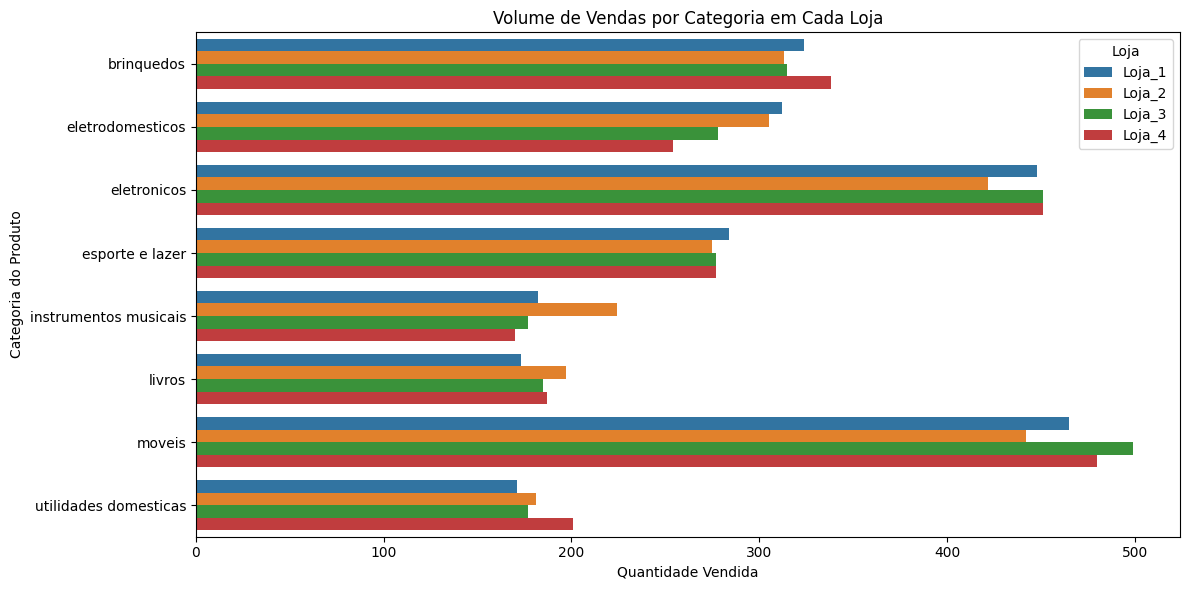

In [48]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_agg, x='quantidade_vendida', y='Categoria do Produto', hue='loja', dodge=True)
plt.title('Volume de Vendas por Categoria em Cada Loja')
plt.xlabel('Quantidade Vendida')
plt.ylabel('Categoria do Produto')
plt.legend(title='Loja')
plt.tight_layout()
plt.show()


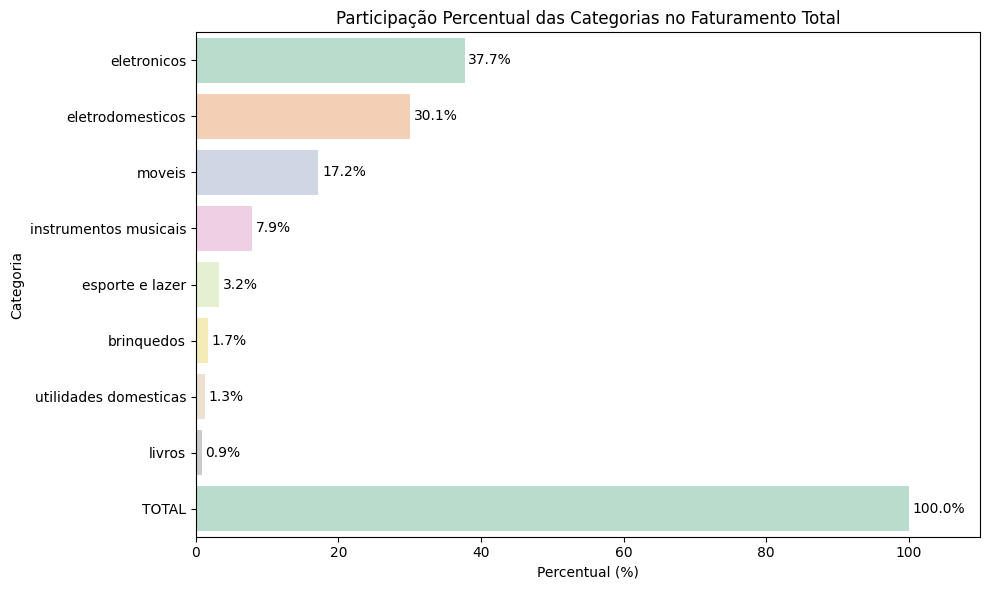

In [49]:
# 1️⃣ Agrupa por categoria para somar o faturamento
faturamento_categoria = df_geral.groupby('Categoria do Produto')['Preço'].sum().reset_index()

# 2️⃣ Calcula o percentual de participação de cada categoria
faturamento_categoria['percentual'] = (faturamento_categoria['Preço'] / faturamento_categoria['Preço'].sum()) * 100

# 3️⃣ Ordena para ficar visualmente organizado
faturamento_categoria = faturamento_categoria.sort_values('percentual', ascending=False)

# 4️⃣ Adiciona linha TOTAL para visual referência
linha_total = pd.DataFrame({
    'Categoria do Produto': ['TOTAL'],
    'Preço': [faturamento_categoria['Preço'].sum()],
    'percentual': [100.0]
})
faturamento_categoria = pd.concat([faturamento_categoria, linha_total], ignore_index=True)

# 5️⃣ Gera o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    data=faturamento_categoria,
    x='percentual',
    y='Categoria do Produto',
    palette='Pastel2',
    hue='Categoria do Produto',
    dodge=False,
    legend=False
)

# 6️⃣ Insere os rótulos com os percentuais
for i, row in faturamento_categoria.iterrows():
    plt.text(row['percentual'] + 0.5, i, f"{row['percentual']:.1f}%", va='center')

plt.xlim(0, 110)
plt.title('Participação Percentual das Categorias no Faturamento Total')
plt.xlabel('Percentual (%)')
plt.ylabel('Categoria')
plt.tight_layout()
plt.show()


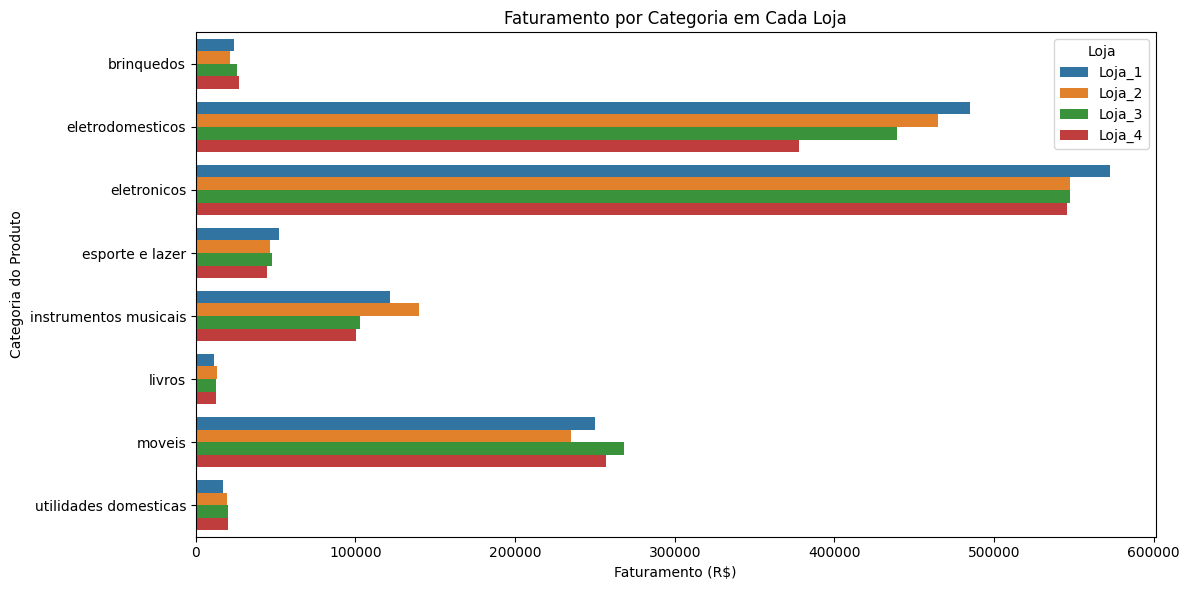

In [34]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_agg, x='faturamento', y='Categoria do Produto', hue='loja', dodge=True)
plt.title('Faturamento por Categoria em Cada Loja')
plt.xlabel('Faturamento (R$)')
plt.ylabel('Categoria do Produto')
plt.legend(title='Loja')
plt.tight_layout()
plt.show()


# 3. Média de Avaliação das Lojas

# 4. Produtos Mais e Menos Vendidos

### Análise de Produtos Mais Vendidos - Geral e Por Loja

In [66]:
# Contagem dos produtos mais vendidos
produtos_mais_vendidos = df_geral['Produto'].value_counts().sort_values(ascending=False)

# Adiciona uma linha de total
produtos_mais_vendidos.loc['TOTAL'] = produtos_mais_vendidos.sum()

# Exibir o TOP 10
produtos_mais_vendidos

Produto
Cômoda                          210
Carrinho controle remoto        206
Micro-ondas                     206
Bateria                         203
Cama king                       201
Jogo de panelas                 200
Secadora de roupas              200
Modelagem preditiva             200
Cama box                        199
Blocos de montar                199
Celular Plus X42                198
Bola de basquete                197
Guarda roupas                   197
Pandeiro                        197
Bicicleta                       196
Iniciando em programação        195
Smart TV                        192
Geladeira                       191
Lava louças                     189
Faqueiro                        189
Violão                          188
Impressora                      188
Kit banquetas                   188
Copo térmico                    187
TV Led UHD 4K                   187
Fogão                           187
Corda de pular                  186
Mesa de jantar      

In [68]:
# Contagem de produtos vendidos por loja
produtos_por_loja = df_geral.groupby(['loja', 'Produto']).size().reset_index(name='quantidade')

# Para visualizar os produtos mais vendidos por loja (top 5 de cada loja)
top_produtos_por_loja = produtos_por_loja.sort_values(['loja', 'quantidade'], ascending=[True, False])

# Exibir top 5 de cada loja
top_5_por_loja = top_produtos_por_loja.groupby('loja').head(5)
top_5_por_loja

,loja,Produto,quantidade
24,Loja_1,Guarda roupas,60
37,Loja_1,Micro-ondas,60
47,Loja_1,TV Led UHD 4K,60
43,Loja_1,Secadora de roupas,58
3,Loja_1,Blocos de montar,56
79,Loja_2,Iniciando em programação,65
88,Loja_2,Micro-ondas,62
52,Loja_2,Bateria,61
91,Loja_2,Pandeiro,58
100,Loja_2,Violão,58


### Análise de Produtos Menos Vendidos - Geral e Por Loja

In [65]:
# Contagem dos produtos menos vendidos
produtos_menos_vendidos = df_geral['Produto'].value_counts().sort_values(ascending=True)

# Adiciona uma linha de total
produtos_menos_vendidos.loc['TOTAL'] = produtos_menos_vendidos.sum()

# Exibir o TOP 10
produtos_menos_vendidos

Produto
Celular ABXY                    157
Headset                         158
Mochila                         163
Guitarra                        165
Ciência de dados com python     166
Assistente virtual              167
Poltrona                        168
Jogo de copos                   169
Panela de pressão               172
Smartwatch                      172
Fone de ouvido                  174
Jogo de tabuleiro               175
Boneca bebê                     175
Mesa de centro                  175
Dinossauro Rex                  175
Lavadora de roupas              176
Tablet ABXY                     179
Xadrez de madeira               180
Cubo mágico 8x8                 180
Cadeira de escritório           181
Dashboards com Power BI         181
Sofá retrátil                   182
Bola de vôlei                   184
Mesa de jantar                  185
Corda de pular                  186
TV Led UHD 4K                   187
Fogão                           187
Copo térmico        

In [70]:
# Contagem de produtos vendidos por loja
produtos_por_loja = df_geral.groupby(['loja', 'Produto']).size().reset_index(name='quantidade')

# Para visualizar os produtos mais vendidos por loja (top 5 de cada loja)
top_produtos_por_loja = produtos_por_loja.sort_values(['loja', 'quantidade'], ascending=[True, True])

# Exibir top 5 de cada loja
top_5_por_loja = top_produtos_por_loja.groupby('loja').head(5)
top_5_por_loja

,loja,Produto,quantidade
11,Loja_1,Celular ABXY,33
26,Loja_1,Headset,33
41,Loja_1,Panela de pressão,35
40,Loja_1,Pandeiro,36
13,Loja_1,Ciência de dados com python,39
82,Loja_2,Jogo de tabuleiro,32
78,Loja_2,Impressora,34
87,Loja_2,Mesa de jantar,34
93,Loja_2,Poltrona,35
73,Loja_2,Fone de ouvido,37


# 5. Frete Médio por Loja


# Relatório do Projeto